In [1]:
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn.functional as F
from PIL import Image
from scipy import ndimage
import matplotlib.pyplot as plt
import os

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")

MEMORY_BANK_PATH = os.path.expanduser('~/Documents/SemiAD/memory_banks')

# Multi-scale feature extractor — layer2 + layer3
class MultiScaleFeatureExtractor(torch.nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.early = torch.nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu,
            backbone.maxpool, backbone.layer1, backbone.layer2
        )
        self.late = backbone.layer3

    def forward(self, x):
        layer2_out = self.early(x)
        layer3_out = self.late(layer2_out)
        layer2_resized = F.interpolate(layer2_out, size=layer3_out.shape[2:], mode='bilinear', align_corners=False)
        return torch.cat([layer2_resized, layer3_out], dim=1)

backbone = models.resnet18(pretrained=True)
feature_extractor = MultiScaleFeatureExtractor(backbone).to(device)
for param in feature_extractor.parameters():
    param.requires_grad = False
feature_extractor.eval()

# Load all three memory banks
memory_banks = {}
for name in ['ball_side', 'chip_side', 'wafer']:
    memory_banks[name] = torch.load(f'{MEMORY_BANK_PATH}/{name}_memory_bank.pt', map_location='cpu')
    print(f"Loaded {name} memory bank: {memory_banks[name].shape}")


Device: mps


/Users/zabir/Documents/SemiAD/semiad_env/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/zabir/Documents/SemiAD/semiad_env/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded ball_side memory bank: torch.Size([142899, 384])
Loaded chip_side memory bank: torch.Size([175872, 384])
Loaded wafer memory bank: torch.Size([113230, 384])


In [ ]:
import os
import numpy as np
from tqdm import tqdm

SCORE_SAVE_PATH = '/Users/zabir/Documents/SemiAD/scores'
os.makedirs(SCORE_SAVE_PATH, exist_ok=True)

def score_folder_with_names(folder, memory_bank, img_size):
    scores = []
    filenames = []
    files = sorted([f for f in os.listdir(folder)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))])
    memory_bank_gpu = memory_bank.to(device)
    transform = get_transform(img_size)
    for fname in tqdm(files, desc=os.path.basename(folder)):
        fpath = f'{folder}/{fname}'
        img = Image.open(fpath).convert('RGB')
        tensor = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            features = feature_extractor(tensor)
            b, c, h, w = features.shape
            features = features.permute(0, 2, 3, 1).reshape(b, h*w, c)[0]
            distances = torch.cdist(features, memory_bank_gpu)
            min_distances, _ = distances.min(dim=1)
            scores.append(min_distances.max().item())
            filenames.append(fpath)
    return np.array(scores), filenames

for name, config in SUBSETS.items():
    base = config['path']
    img_size = config['img_size']
    subset_path = f'{SCORE_SAVE_PATH}/{name}'
    os.makedirs(subset_path, exist_ok=True)

    print(f"\n{'='*50}")
    print(f"Subset: {name.upper()}")
    print(f"{'='*50}")

    print("Scoring normal images...")
    good_scores, good_files = score_folder_with_names(
        f'{base}/single_set/test/good',
        memory_banks[name],
        img_size
    )

    print("Scoring defect images...")
    defect_scores, defect_files = score_folder_with_names(
        f'{base}/single_set/test/defect',
        memory_banks[name],
        img_size
    )

    # Save everything
    np.save(f'{subset_path}/good_scores.npy', good_scores)
    np.save(f'{subset_path}/defect_scores.npy', defect_scores)
    np.save(f'{subset_path}/good_files.npy', np.array(good_files))
    np.save(f'{subset_path}/defect_files.npy', np.array(defect_files))

    print(f"\nNormal — min: {good_scores.min():.4f}, max: {good_scores.max():.4f}, mean: {good_scores.mean():.4f}")
    print(f"Defect — min: {defect_scores.min():.4f}, max: {defect_scores.max():.4f}, mean: {defect_scores.mean():.4f}")
    print(f"{name} saved")


Subset: BALL_SIDE
Scoring normal images...


good: 100%|██████████| 5018/5018 [03:55<00:00, 21.31it/s]


Scoring defect images...


defect: 100%|██████████| 324/324 [00:14<00:00, 22.58it/s]



Normal — min: 1.5649, max: 5.9217, mean: 3.2858
Defect — min: 2.5419, max: 6.5899, mean: 4.2011
ball_side saved

Subset: CHIP_SIDE
Scoring normal images...


...


Normal — min: 1.1595, max: 6.2638, mean: 3.2836
Defect — min: 2.5886, max: 6.7936, mean: 4.3702
chip_side saved

Subset: WAFER
Scoring normal images...


good: 100%|██████████| 4784/4784 [02:35<00:00, 30.84it/s]


Scoring defect images...


defect: 100%|██████████| 336/336 [00:10<00:00, 33.22it/s]


Normal — min: 0.9659, max: 5.6844, mean: 2.3946
Defect — min: 1.1115, max: 7.0248, mean: 4.4195
wafer saved


In [6]:
# ==================================================
# Subset: BALL_SIDE
# ==================================================
# Scoring normal images...
# good: 100%|██████████| 5018/5018 [04:04<00:00, 20.51it/s]
# Scoring defect images...
# defect: 100%|██████████| 324/324 [00:14<00:00, 21.71it/s]

# Normal — min: 1.5649, max: 5.9217, mean: 3.2858
# Defect — min: 2.5419, max: 6.5899, mean: 4.2011

# ==================================================
# Subset: CHIP_SIDE
# ==================================================
# Scoring normal images...
# good: 100%|██████████| 5353/5353 [05:08<00:00, 17.34it/s]
# Scoring defect images...
# defect: 100%|██████████| 147/147 [00:08<00:00, 16.83it/s]

# Normal — min: 1.1595, max: 6.2638, mean: 3.2836
# Defect — min: 2.5886, max: 6.7936, mean: 4.3702

# ==================================================
# Subset: WAFER
# ==================================================
# Scoring normal images...
# good: 100%|██████████| 4784/4784 [02:30<00:00, 31.70it/s]
# Scoring defect images...
# defect: 100%|██████████| 336/336 [00:10<00:00, 32.01it/s]

# Normal — min: 0.9659, max: 5.6844, mean: 2.3946
# Defect — min: 1.1115, max: 7.0248, mean: 4.4195

In [18]:
SCORE_SAVE_PATH = '/Users/zabir/Documents/SemiAD/scores'

all_scores = {}
for name in SUBSETS.keys():
    subset_path = f'{SCORE_SAVE_PATH}/{name}'
    all_scores[name] = {
        'good_scores':   np.load(f'{subset_path}/good_scores.npy'),
        'defect_scores': np.load(f'{subset_path}/defect_scores.npy'),
        'good_files':    np.load(f'{subset_path}/good_files.npy').tolist(),
        'defect_files':  np.load(f'{subset_path}/defect_files.npy').tolist()
    }
    print(f'{name} loaded')

ball_side loaded
chip_side loaded
wafer loaded


Anomaly Score: 4.6658


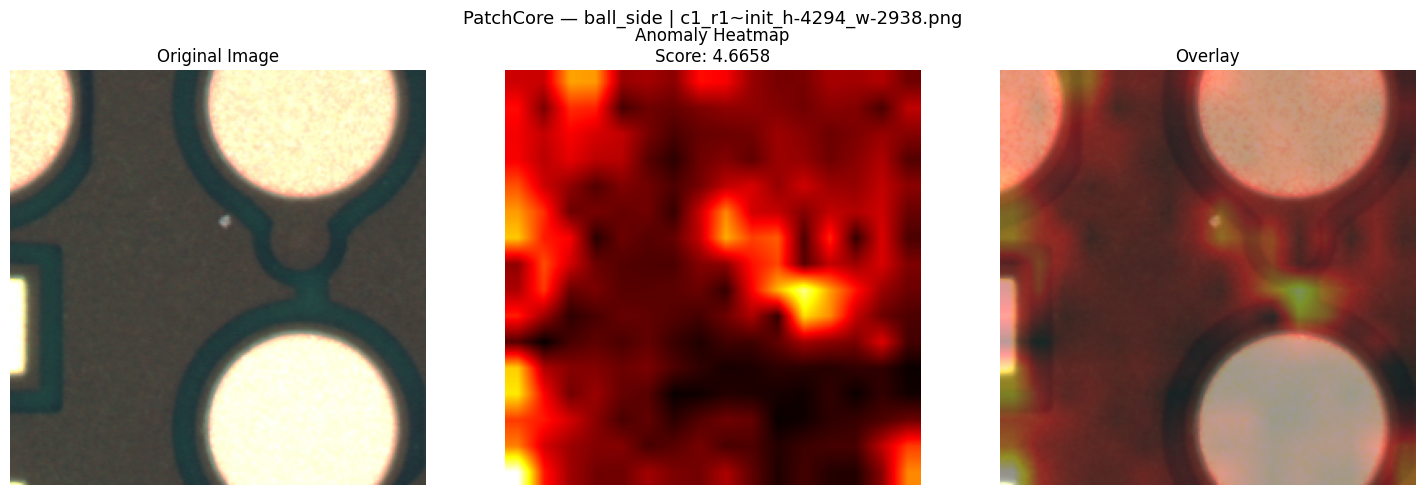

Verdict: LIKELY DEFECTIVE — above defect mean
Reference — Normal mean: 2.3946, Defect mean: 4.4195


In [19]:
# USER INPUT 
IMAGE_PATH = '//Users/zabir/Downloads/semi-AD/semi-AD/IC_substrate/ball_side/single_set/test/defect/c1_r1~init_h-4294_w-2938.png'
SUBSET     = 'ball_side'  # 'ball_side', 'chip_side', 'wafer'

img_size = 200 if SUBSET == 'wafer' else 256

# Load and preprocess image
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

img_pil = Image.open(IMAGE_PATH).convert('RGB')
img_tensor = transform(img_pil).unsqueeze(0).to(device)

# Extract features and compute anomaly map
memory_bank_gpu = memory_banks[SUBSET].to(device)
feature_extractor.eval()
with torch.no_grad():
    features = feature_extractor(img_tensor)
    b, c, h, w = features.shape
    features = features.permute(0, 2, 3, 1).reshape(b, h*w, c)[0]
    distances = torch.cdist(features, memory_bank_gpu)
    min_distances, _ = distances.min(dim=1)
    side = int(min_distances.shape[0] ** 0.5)
    anomaly_map = min_distances.reshape(side, side).cpu().numpy()
    anomaly_map = np.array(Image.fromarray(anomaly_map).resize(
        (img_size, img_size), Image.BILINEAR))

# Anomaly score = max patch distance
anomaly_score = anomaly_map.max()
print(f"Anomaly Score: {anomaly_score:.4f}")

# Denormalize original image for display
orig = img_tensor[0].cpu().permute(1, 2, 0).numpy()
orig = orig * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
orig = np.clip(orig, 0, 1)

# Plot — original, heatmap, overlay
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(orig)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(anomaly_map, cmap='hot')
axes[1].set_title(f'Anomaly Heatmap\nScore: {anomaly_score:.4f}')
axes[1].axis('off')

axes[2].imshow(orig)
axes[2].imshow(anomaly_map, cmap='hot', alpha=0.4)
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.suptitle(f'PatchCore — {SUBSET} | {os.path.basename(IMAGE_PATH)}', fontsize=13)
plt.tight_layout()
plt.show()

# Wafer reference score ranges (computed from full test set)
good_mean, good_max = 2.3946, 5.6844
defect_mean, defect_max = 4.4195, 7.0248

if anomaly_score < good_mean:
    verdict = "NORMAL — below average normal score"
elif anomaly_score < (good_mean + defect_mean) / 2:
    verdict = "LIKELY NORMAL — above normal mean but below midpoint"
elif anomaly_score < defect_mean:
    verdict = "AMBIGUOUS — in overlap zone"
else:
    verdict = "LIKELY DEFECTIVE — above defect mean"

print(f"Verdict: {verdict}")
print(f"Reference — Normal mean: {good_mean:.4f}, Defect mean: {defect_mean:.4f}")